In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# ※ naver open API를 활용
1. 네이버 지식인 '전주여행' 과 '경주여행'을 검색(re ? 정규표현식) 크롤링 하여 데이터프레임을 만들어 저장
2. 품사태깅 후 백업, 이후 명사만 추출
3. 빈도분석(DataFrame)-> 빈도 시각화(워드클라우드, Text, dispersion_plot)
4. Word2Vec

# 1. 네이버 오픈 API 활용하여 검색 df 만들기
- 검색어, no, title, link, description, title + ' ' + description (total_text)

In [1]:
import pandas as pd
import json
import requests
import os
import sys
import urllib.request
from dotenv import load_dotenv  
load_dotenv()

True

In [7]:
os.getcwd() # 현재 작업디렉토리

'C:\\ai_x\\source\\07_자연어처리'

In [8]:
%ls .env

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\ai_x\source\07_자연어처리 디렉터리

2025-06-18  오후 05:49                58 .env
               1개 파일                  58 바이트
               0개 디렉터리  109,824,954,368 바이트 남음


In [2]:
# 정규표현식 점검하는 함수
def re_keyword(sentence):
    import re
    from html import unescape
    sentence = unescape(sentence)
    sentence = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', sentence)
    sentence = re.sub('\s+', ' ', sentence)
    return sentence

In [5]:

def naver_kin_get_500(keyword):
    client_id = os.getenv('Client_ID')
    client_secret = os.getenv('Client_Secret')
    encText = urllib.parse.quote(keyword)
    display_ = 100
    start = 1
    data = []
    idx=0
    for i in range(5):
        url = f"https://openapi.naver.com/v1/search/kin.json?query={encText}&display={display_}&start={start}"   # JSON 결과
        request = urllib.request.Request(url)
        request.add_header("X-Naver-Client-Id",client_id)
        request.add_header("X-Naver-Client-Secret",client_secret)
        response = urllib.request.urlopen(request)
        rescode = response.getcode()
        if(rescode==200):
            
            item_list = json.loads(response.read())['items']
            for item in item_list:
                title = item.get('title').replace('<b>', '').replace('</b>', '')
                link = item.get('link')
                description = item.get('description').replace('<b>', '').replace('</b>', '')
                description = re_keyword(description)
                data.append([keyword,
                             idx,
                             title,
                             link,
                             description,
                             title+' '+description
                            ])
                idx+=1
            start +=1                          
        else:
            print("Error Code:" + rescode)
    df = pd.DataFrame(data, columns=['검색어', 'no', 'title', 'link', 'description', 'total_text'])
    return df
df1 = naver_kin_get_500('전주여행')
df2 = naver_kin_get_500('경주여행')
df = pd.concat([df1, df2], axis=0).reset_index(drop=True)
df.iloc[::100]

,검색어,no,title,link,description,total_text
0,전주여행,0,전주 가볼만한곳 추천 받아요,https://kin.naver.com/qna/detail.naver?d1id=9&...,추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전...,전주 가볼만한곳 추천 받아요 추억의 7080 다양한체험 7080감성 추억여행 테마...
100,전주여행,100,전주여행갈려고하는데요!,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주여행을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은가격에 정했고 음 2박3...,전주여행갈려고하는데요! 전주여행을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은...
200,전주여행,200,전주 1박 2일 여행 관련 질문~,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주 여행을 계획하고 계시다니 정말 좋은 선택을 하셨네요 전주는 한옥마을과 함께 ...,전주 1박 2일 여행 관련 질문~ 전주 여행을 계획하고 계시다니 정말 좋은 선택을...
300,전주여행,300,중2 여학생 친구와 전주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,안녕하세요 중 2 15살 여학생입니다 친한친구와 둘이서 전주 여행을 가기로 했는데 ...,중2 여학생 친구와 전주여행 안녕하세요 중 2 15살 여학생입니다 친한친구와 둘이서...
400,전주여행,400,부모닝 모시고 전주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,부모님 모시고 전주여행가려는데 명소 식당 추천부탁드립니다 전주는 한옥마을로 유명한 ...,부모닝 모시고 전주여행 부모님 모시고 전주여행가려는데 명소 식당 추천부탁드립니다 전...
500,경주여행,0,추석에 경주 여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,추석에 경주 여행 가는거 어떻게 생각하시나요 서울에서 버스를 타고 갈 경우 버스가 ...,추석에 경주 여행 추석에 경주 여행 가는거 어떻게 생각하시나요 서울에서 버스를 타고...
600,경주여행,100,1박2일 경주 여행 일정 짜주세요,https://kin.naver.com/qna/detail.naver?d1id=9&...,1박2일 경주 여행 일정 짜주세요 질문자님 경주에서의 1박 2일 여행을 계획 중이시...,1박2일 경주 여행 일정 짜주세요 1박2일 경주 여행 일정 짜주세요 질문자님 경주에...
700,경주여행,200,어머니랑 1박2일 경주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,이제 5월달 어버이날을 위해 어머니랑 경주 여행을 할려고합니다 놀러갈데는 다 정했는...,어머니랑 1박2일 경주여행 이제 5월달 어버이날을 위해 어머니랑 경주 여행을 할려고...
800,경주여행,300,경주 여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,5월6 7 8일 경주 여행을 가는데요 동궁과월지와 월정교 야경을 보고 싶은데 7일에...,경주 여행 5월6 7 8일 경주 여행을 가는데요 동궁과월지와 월정교 야경을 보고 싶...
900,경주여행,400,경주여행 30만원,https://kin.naver.com/qna/detail.naver?d1id=9&...,경주 여행 2박3일 남자친구랑 가는데 숙소랑 ktx비는 다 냈고 제 개인적으로 30...,경주여행 30만원 경주 여행 2박3일 남자친구랑 가는데 숙소랑 ktx비는 다 냈고 ...


In [59]:
df.to_csv('data/전주여행_경주여행_사람인.csv', index=False, sep='\t')

In [53]:
df.iloc[558]

검색어                                                         경주여행
no                                                            58
title                                                 경주여행(숙소추천)
link           https://kin.naver.com/qna/detail.naver?d1id=9&...
description    안녕하세요 경기도권에 사는 사람입니다 내년 1월 중순쯤 경주여행을 갈 예정입니다 인...
Name: 558, dtype: object

# 2. 품사 태깅

In [14]:
import pandas as pd
df = pd.read_csv('data/전주여행_경주여행_사람인.csv', sep='\t')

In [19]:
import psutil
psutil.virtual_memory()

svmem(total=16948912128, available=11976744960, percent=29.3, used=4972167168, free=11976744960)

In [22]:
total_text1 = df.loc[df['검색어']=='전주여행','total_text']
total_text2 = df.loc[df['검색어']=='경주여행','total_text']

In [27]:
from mecab import MeCab
mecab = MeCab()

In [28]:
tagged_text1 = [ mecab.pos(text) for text in total_text1]
tagged_text2 = [ mecab.pos(text) for text in total_text2]

In [44]:
list_ = []
for el in tagged_text1:
    for word, tag in el:
        list_.append({'words': word, 
                      'tag' : tag})
df_tags_j = pd.DataFrame(list_)

list_ = []
for el in tagged_text2:
    for word, tag in el:
        list_.append({'words': word, 
                      'tag' : tag})
df_tags_k = pd.DataFrame(list_)
# 백업
df_tags_j.to_csv('data/naver_kin_j_tag.csv', index=False)
df_tags_k.to_csv('data/naver_kin_k_tag.csv', index=False)

In [51]:
np.array(df_tags_j).shape

(30677, 2)

# 3. 빈도분석(DataFrame)

In [48]:
import numpy as np

In [88]:
list_j = df_tags_j.to_numpy().tolist()
list_k = df_tags_k.to_numpy().tolist()
nouns_list1 = [token for token, tag in list_j if tag.startswith('N') and len(token)>=2]
nouns_list2 = [token for token, tag in list_k if tag.startswith('N') and len(token)>=2]


AttributeError: 'list' object has no attribute 'value_counts'

# 4. 빈도 시각화(워드클라우드, Text, dispersion_plot)

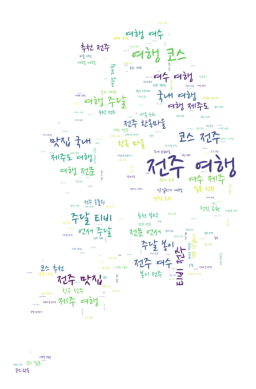

In [90]:
import cv2
from wordcloud import WordCloud
from matplotlib import pyplot as plt
jeonju = ' '.join(nouns_list1)
mask = cv2.imread('data/south_korea.png' )
wordc = WordCloud(font_path='data/NanumPenScript-Regular.ttf', 
                  width = 1000,
                  scale=0.8, 
                  max_font_size= 200, 
                  max_words=200,
                  background_color= 'white', mask=mask)
wordc.generate(jeonju)
plt.imshow(wordc)
plt.axis('off')
plt.show()
wordc.to_file('jeonju.jpg')

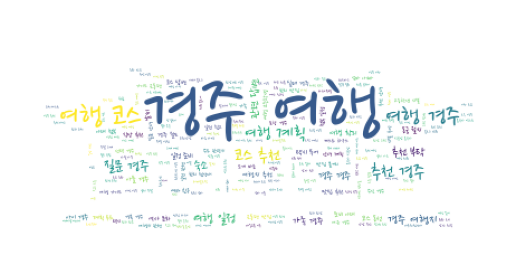

In [91]:
kyungju = ' '.join(nouns_list2)
mask = cv2.imread('data/korea-house-black-fill.png')
wordc = WordCloud(font_path='data/NanumPenScript-Regular.ttf', 
                  width = 2000,
                  scale=0.8, 
                  max_font_size= 200, 
                  max_words=200,
                  background_color= 'white', mask=mask)
wordc.generate(kyungju)
plt.imshow(wordc)
plt.axis('off')
#plt.figure(figsize=(12,6))
plt.show()
wordc.to_file('kyungju.jpg')

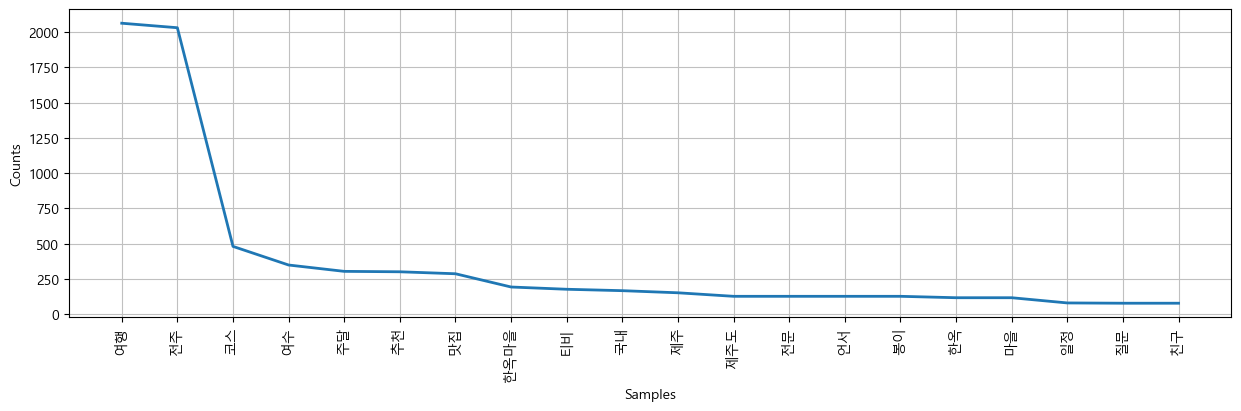

In [92]:
# Text 객체 이용 시각화
import nltk
data_text1 = nltk.Text(nouns_list1)
plt.figure(figsize=(15,4))
data_text1.plot(20)
plt.show()

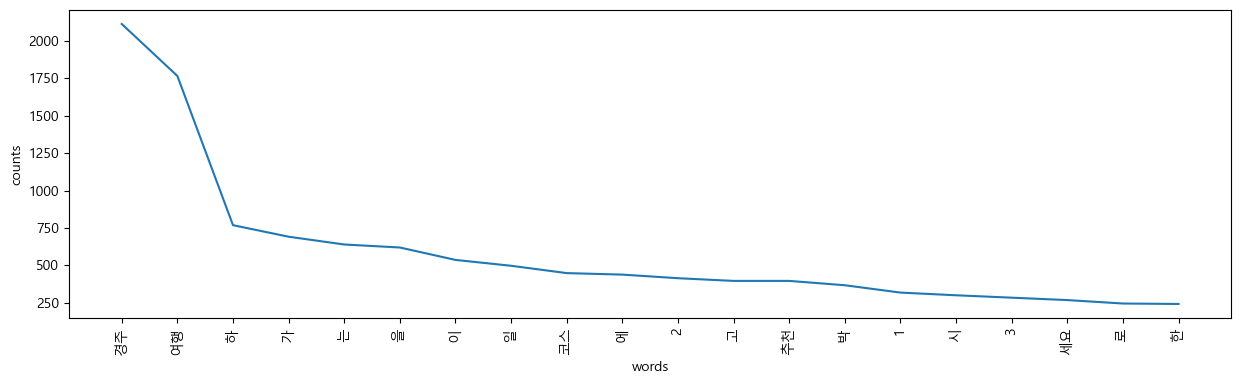

In [85]:
data_text2 = nltk.Text(nouns_list2)
words, counts = zip(*data_text2.vocab().most_common(20))

plt.figure(figsize=(15,4))
plt.plot(words, counts)
plt.xticks(rotation=90)
plt.xlabel('words')
plt.ylabel('counts')
plt.show()

# 5. Word2Vec

In [127]:
# 전주 여행 키워드 리스트
noun_list1 = []
for el in tagged_text1:
    noun_list1.append([token for token, tag in el if tag in('NNG', 'NNP')])
# 경주 여행 키워드 리스트    
noun_list2 = []
for el in tagged_text2:
    noun_list2.append([token for token, tag in el if tag in('NNG', 'NNP')])

In [133]:
from gensim.models import Word2Vec
model1 = Word2Vec(noun_list1,  # 학습데이터(2차원)
                window=10, # 각 단어의 좌우 10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습
                workers= -1, # 병렬처리 코어 수, -1 : 가용 코어 전체 사용
                )
model2 = Word2Vec(noun_list2,  # 학습데이터(2차원)
                window=10, # 각 단어의 좌우 10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습
                workers= -1, # 병렬처리 코어 수, -1 : 가용 코어 전체 사용
                )

In [134]:
model1.wv.most_similar('전주')

[('하트', 0.3641005754470825),
 ('값', 0.21867415308952332),
 ('화', 0.2159893959760666),
 ('순서', 0.21469099819660187),
 ('중심', 0.2134207934141159),
 ('정', 0.20906010270118713),
 ('날짜', 0.2070489227771759),
 ('징', 0.19909146428108215),
 ('주식', 0.19833795726299286),
 ('계획', 0.18890605866909027)]

In [135]:
model2.wv.most_similar('경주')

[('전남', 0.3595535457134247),
 ('시내', 0.2897421419620514),
 ('친정', 0.275379478931427),
 ('초등', 0.2731468081474304),
 ('이동', 0.2295033037662506),
 ('가격', 0.22023281455039978),
 ('차', 0.21883943676948547),
 ('답변', 0.21617142856121063),
 ('엑스포', 0.20657561719417572),
 ('용시', 0.20463387668132782)]